# Analisis Keamanan Steganografi DCT vs IWT

Notebook ini melakukan eksperimen steganografi citra grayscale berbasis transformasi frekuensi menggunakan:
- **DCT (Discrete Cosine Transform)** dengan SciPy (scipy.fftpack)
- **IWT (Integer Wavelet Transform)** dengan PyWavelets

Instrumen pengukuran analisis keamanan dan kualitas citra:
- Library **scikit-image** untuk metrik kualitas: MSE, PSNR, SSIM
- Library **NumPy** untuk komputasi keamanan: NPCR, UACI

Evaluasi yang dihitung:
- Kualitas citra: **MSE, PSNR, SSIM** (menggunakan scikit-image)
- Keamanan perubahan piksel: **NPCR, UACI** (berbasis NumPy)

Hasil mencakup visualisasi citra, histogram, tabel metrik, penyimpanan file hasil, dan kesimpulan otomatis.

In [ ]:
# Instal dependensi (jalankan sekali di Colab)
!pip -q install scipy pywavelets scikit-image opencv-python-headless numpy

In [ ]:
import os
import cv2
import pywt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct

from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
from google.colab import files

np.random.seed(42)

In [ ]:
# 0) Setup folder struktur untuk upload dan hasil
import shutil
from pathlib import Path

# Buat folder utama
folders = {
    'uploads': './uploads',
    'results_single': './hasil/single_image',
    'results_batch': './hasil/batch_images',
    'extracted_messages': './hasil/extracted_messages'
}

for folder_name, folder_path in folders.items():
    Path(folder_path).mkdir(parents=True, exist_ok=True)
    print(f'✓ Folder siap: {folder_path}')

print('\n=== STRUKTUR FOLDER ===')
print('./uploads/                    # Tempat menyimpan file upload')
print('./hasil/')
print('  ├── single_image/           # Hasil analisis single image')
print('  ├── batch_images/           # Hasil analisis batch images')
print('  └── extracted_messages/     # Pesan yang berhasil diekstrak')


✓ Folder siap: ./uploads
✓ Folder siap: ./hasil/single_image
✓ Folder siap: ./hasil/batch_images
✓ Folder siap: ./hasil/extracted_messages

=== STRUKTUR FOLDER ===
./uploads/                    # Tempat menyimpan file upload
./hasil/
  ├── single_image/           # Hasil analisis single image
  ├── batch_images/           # Hasil analisis batch images
  └── extracted_messages/     # Pesan yang berhasil diekstrak


In [ ]:
# 1) Upload dan preprocessing citra
TARGET_SIZE = (512, 512)

uploaded = files.upload()
if len(uploaded) == 0:
    raise ValueError('Tidak ada file yang di-upload.')

filename = next(iter(uploaded.keys()))
file_bytes = np.frombuffer(uploaded[filename], np.uint8)
img_bgr = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

if img_bgr is None:
    raise ValueError('File tidak dapat dibaca sebagai citra.')

# Konversi ke grayscale jika diperlukan
cover_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if len(img_bgr.shape) == 3 else img_bgr
# Resize agar seragam
cover_gray = cv2.resize(cover_gray, TARGET_SIZE, interpolation=cv2.INTER_AREA)

print(f'Nama file: {filename}')
print(f'Ukuran citra setelah preprocessing: {cover_gray.shape}')

Saving t001.png to t001.png
Nama file: t001.png
Ukuran citra setelah preprocessing: (512, 512)


In [ ]:
# 2) Generate watermark/pesan rahasia (matriks numerik biner)
WM_SIZE = (64, 64)
watermark = np.random.randint(0, 2, WM_SIZE, dtype=np.uint8)

print('Contoh watermark (5x5):')
print(watermark[:5, :5])

Contoh watermark (5x5):
[[0 0 1 1 1]
 [1 0 0 1 1]
 [1 1 0 1 1]
 [1 0 1 0 1]
 [0 0 1 0 1]]


In [ ]:
# 2a) Fungsi konversi teks ke biner dan sebaliknya
def text_to_binary(text):
    """
    Konversi teks ASCII ke string biner.
    Contoh: "A" -> "01000001"
    """
    binary = ''.join(format(ord(char), '08b') for char in text)
    return binary

def binary_to_text(binary_str):
    """
    Konversi string biner kembali ke teks ASCII.
    Contoh: "01000001" -> "A"
    """
    # Pastikan panjang string biner kelipatan 8
    if len(binary_str) % 8 != 0:
        binary_str = binary_str[:-(len(binary_str) % 8)]

    text = ''.join(chr(int(binary_str[i:i+8], 2)) for i in range(0, len(binary_str), 8))
    return text

# Test konversi
test_msg = "Halo"
test_bin = text_to_binary(test_msg)
test_back = binary_to_text(test_bin)
print(f'Teks: {test_msg}')
print(f'Biner: {test_bin}')
print(f'Kembali ke teks: {test_back}')
print(f'Panjang biner: {len(test_bin)} bit')


Teks: Halo
Biner: 01001000011000010110110001101111
Kembali ke teks: Halo
Panjang biner: 32 bit


In [ ]:
# 2b) Upload file txt untuk pesan atau gunakan watermark acak
print('=== Pilihan Input Pesan ===')
print('1. Upload file txt (untuk pesan rahasia)')
print('2. Gunakan watermark acak (default)')

upload_choice = input('Pilih 1 atau 2 (default=2): ').strip()

if upload_choice == '1':
    print('\nUpload file txt:')
    txt_uploaded = files.upload()

    if len(txt_uploaded) == 0:
        print('Tidak ada file yang di-upload. Menggunakan watermark acak.')
        watermark = np.random.randint(0, 2, WM_SIZE, dtype=np.uint8)
        use_text_message = False
    else:
        txt_filename = next(iter(txt_uploaded.keys()))
        txt_content = txt_uploaded[txt_filename].decode('utf-8', errors='ignore')

        # Konversi teks ke biner
        message_binary = text_to_binary(txt_content)
        print(f'\nFile: {txt_filename}')
        print(f'Pesan: {txt_content[:100]}...' if len(txt_content) > 100 else f'Pesan: {txt_content}')
        print(f'Panjang pesan: {len(txt_content)} karakter')
        print(f'Panjang biner: {len(message_binary)} bit')

        # Hitung kapasitas
        total_capacity = WM_SIZE[0] * WM_SIZE[1]
        print(f'Kapasitas tersedia: {total_capacity} bit')

        if len(message_binary) > total_capacity:
            print(f' PESAN TERLALU PANJANG! Maksimal {total_capacity // 8} karakter.')
            print('Menggunakan watermark acak sebagai alternatif.')
            watermark = np.random.randint(0, 2, WM_SIZE, dtype=np.uint8)
            use_text_message = False
        else:
            # Padding dengan nol jika perlu
            message_binary_padded = message_binary.ljust(total_capacity, '0')
            watermark = np.array([int(bit) for bit in message_binary_padded], dtype=np.uint8).reshape(WM_SIZE)
            use_text_message = True
            print('✓ Pesan berhasil dikonversi ke watermark biner.')
else:
    print('\nMenggunakan watermark acak.')
    watermark = np.random.randint(0, 2, WM_SIZE, dtype=np.uint8)
    use_text_message = False

print(f'\nWatermark shape: {watermark.shape}')
print('Contoh watermark (5x5):')
print(watermark[:5, :5])


=== Pilihan Input Pesan ===
1. Upload file txt (untuk pesan rahasia)
2. Gunakan watermark acak (default)
Pilih 1 atau 2 (default=2): 1

Upload file txt:


Saving pesan.txt to pesan.txt

File: pesan.txt
Pesan: apa hayo
Panjang pesan: 8 karakter
Panjang biner: 64 bit
Kapasitas tersedia: 4096 bit
✓ Pesan berhasil dikonversi ke watermark biner.

Watermark shape: (64, 64)
Contoh watermark (5x5):
[[0 1 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


In [ ]:
# 3) Fungsi embedding DCT (block-wise 8x8) menggunakan SciPy
def embed_dct(cover_img, watermark_bits, alpha=10.0):
    """
    Menyisipkan bit watermark ke koefisien DCT pada setiap blok 8x8
    dengan membandingkan pasangan koefisien (3,4) dan (4,3).
    Menggunakan scipy.fftpack.dct untuk transformasi DCT.
    """
    h, w = cover_img.shape
    stego = cover_img.astype(np.float32).copy()

    if h % 8 != 0 or w % 8 != 0:
        raise ValueError('Ukuran citra harus kelipatan 8 untuk embedding DCT block-wise.')

    blocks_y, blocks_x = h // 8, w // 8
    if watermark_bits.shape != (blocks_y, blocks_x):
        raise ValueError(f'Ukuran watermark harus {(blocks_y, blocks_x)} untuk citra {cover_img.shape}.')

    p1 = (3, 4)
    p2 = (4, 3)

    for by in range(blocks_y):
        for bx in range(blocks_x):
            y0, y1 = by * 8, (by + 1) * 8
            x0, x1 = bx * 8, (bx + 1) * 8

            block = stego[y0:y1, x0:x1]
            # Gunakan scipy.fftpack.dct untuk transformasi DCT
            dct_block = dct(dct(block, axis=0, norm='ortho'), axis=1, norm='ortho')

            b = int(watermark_bits[by, bx])
            c1 = dct_block[p1]
            c2 = dct_block[p2]
            avg = (c1 + c2) / 2.0

            # Aturan embedding: bit 1 -> c1 > c2, bit 0 -> c2 > c1
            if b == 1:
                dct_block[p1] = avg + alpha / 2.0
                dct_block[p2] = avg - alpha / 2.0
            else:
                dct_block[p1] = avg - alpha / 2.0
                dct_block[p2] = avg + alpha / 2.0

            # Gunakan scipy.fftpack.idct untuk inverse DCT
            stego[y0:y1, x0:x1] = idct(idct(dct_block, axis=0, norm='ortho'), axis=1, norm='ortho')

    return np.clip(np.round(stego), 0, 255).astype(np.uint8)

In [ ]:
# 3a) Fungsi ekstraksi watermark dari stego DCT menggunakan SciPy
def extract_dct(stego_img, alpha=10.0):
    """
    Ekstraksi bit watermark dari koefisien DCT pada setiap blok 8x8.
    Membandingkan pasangan koefisien (3,4) dan (4,3).
    Menggunakan scipy.fftpack.dct untuk transformasi DCT.
    """
    h, w = stego_img.shape
    extracted = np.zeros((h // 8, w // 8), dtype=np.uint8)

    if h % 8 != 0 or w % 8 != 0:
        raise ValueError('Ukuran citra harus kelipatan 8.')

    p1 = (3, 4)
    p2 = (4, 3)

    for by in range(h // 8):
        for bx in range(w // 8):
            y0, y1 = by * 8, (by + 1) * 8
            x0, x1 = bx * 8, (bx + 1) * 8

            block = stego_img[y0:y1, x0:x1].astype(np.float32)
            # Gunakan scipy.fftpack.dct untuk transformasi DCT
            dct_block = dct(dct(block, axis=0, norm='ortho'), axis=1, norm='ortho')

            c1 = dct_block[p1]
            c2 = dct_block[p2]

            # Jika c1 > c2, bit adalah 1; sebaliknya 0
            extracted[by, bx] = 1 if c1 > c2 else 0

    return extracted

# 3b) Fungsi ekstraksi watermark dari stego IWT
def extract_iwt(stego_img, wavelet='haar'):
    """
    Ekstraksi bit watermark dari subband LL setelah dekomposisi wavelet.
    Menggunakan PyWavelets (pywt) untuk transformasi wavelet.
    """
    stego_int = stego_img.astype(np.int16)
    LL, (LH, HL, HH) = pywt.dwt2(stego_int, wavelet)

    # Normalisasi nilai LL ke [0, 1]
    LL_min = LL.min()
    LL_max = LL.max()
    LL_norm = (LL - LL_min) / (LL_max - LL_min + 1e-12)

    extracted = (LL_norm > 0.5).astype(np.uint8)

    # Resize ke ukuran standar
    extracted_resized = cv2.resize(extracted.astype(np.float32), (64, 64), interpolation=cv2.INTER_NEAREST)
    return extracted_resized.astype(np.uint8)

In [ ]:
# 4) Fungsi embedding IWT-like (domain wavelet, subband LL)
def embed_iwt_ll(cover_img, watermark_bits, alpha=2.0, wavelet='haar'):
    """
    Menyisipkan watermark pada subband LL setelah dekomposisi wavelet.
    Implementasi menggunakan PyWavelets pada domain integer-terbatas
    (citra dikonversi ke int16, hasil rekonstruksi diklip ke uint8).
    """
    cover_int = cover_img.astype(np.int16)

    LL, (LH, HL, HH) = pywt.dwt2(cover_int, wavelet)

    # Resize watermark ke ukuran LL
    wm_ll = cv2.resize(watermark_bits.astype(np.float32), (LL.shape[1], LL.shape[0]), interpolation=cv2.INTER_NEAREST)
    wm_sign = (wm_ll * 2.0) - 1.0  # 0/1 -> -1/+1

    LL_embedded = LL + alpha * wm_sign

    stego_recon = pywt.idwt2((LL_embedded, (LH, HL, HH)), wavelet)
    stego_recon = np.clip(np.round(stego_recon), 0, 255).astype(np.uint8)

    # Pastikan ukuran sama
    stego_recon = cv2.resize(stego_recon, (cover_img.shape[1], cover_img.shape[0]), interpolation=cv2.INTER_AREA)
    return stego_recon

In [ ]:
# 5) Proses embedding
stego_dct = embed_dct(cover_gray, watermark, alpha=10.0)
stego_iwt = embed_iwt_ll(cover_gray, watermark, alpha=2.0, wavelet='haar')

print('Embedding selesai.')

Embedding selesai.


In [ ]:
# 5b) Ekstraksi watermark dan rekonstruksi pesan
extracted_dct = extract_dct(stego_dct, alpha=10.0)
extracted_iwt = extract_iwt(stego_iwt, wavelet='haar')

print('Ekstraksi watermark selesai.')

# Jika menggunakan pesan txt, rekonstruksi pesannya
if use_text_message:
    # Ekstrak biner dari watermark
    extracted_binary_dct = ''.join(extracted_dct.flatten().astype(str))
    extracted_binary_iwt = ''.join(extracted_iwt.flatten().astype(str))

    # Rekonstruksi teks
    reconstructed_msg_dct = binary_to_text(extracted_binary_dct)
    reconstructed_msg_iwt = binary_to_text(extracted_binary_iwt)

    print('\n=== HASIL EKSTRAKSI PESAN ===')
    print(f'Pesan asli: {txt_content[:100]}...' if len(txt_content) > 100 else f'Pesan asli: {txt_content}')
    print(f'\nHasil ekstraksi DCT: {reconstructed_msg_dct}')
    print(f'Hasil ekstraksi IWT: {reconstructed_msg_iwt}')

    # Hitung akurasi ekstraksi
    acc_dct = np.mean(extracted_dct == watermark) * 100
    acc_iwt = np.mean(extracted_iwt == watermark) * 100

    print(f'\nAkurasi ekstraksi DCT: {acc_dct:.2f}%')
    print(f'Akurasi ekstraksi IWT: {acc_iwt:.2f}%')
else:
    print('\n(Menggunakan watermark acak, tidak ada pesan untuk diekstraksi)')


Ekstraksi watermark selesai.

=== HASIL EKSTRAKSI PESAN ===
Pesan asli: apa hayo

Hasil ekstraksi DCT: apa hayo                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
Hasil ekstraksi IWT: ÿù     ÿù     ÿù     ?ø   ð    ð   @   @     @@             ð   @ð   0ð    ð    ð    ð    ð    ð    ð (  ð    ð    ð     ð     ÿà    ýð    ÷ð  À ûz  ÿï  0Ð½°  aðõ¹   øÿ«Àøxð  @ü<ð  @ü<ð   üà   lð    ð    ð    à    ð     à  8 à  8 à   à   à   

In [ ]:
# 6) Fungsi metrik kualitas dan keamanan
# Menggunakan scikit-image untuk MSE, PSNR, SSIM dan NumPy untuk NPCR, UACI

def compute_npcr(img1, img2):
    """
    NPCR (Number of Pixel Change Rate)
    Menghitung persentase piksel yang berubah antara dua citra.
    Menggunakan NumPy untuk komputasi.
    """
    img1 = img1.astype(np.uint8)
    img2 = img2.astype(np.uint8)
    diff = img1 != img2
    return (np.sum(diff) / diff.size) * 100.0

def compute_uaci(img1, img2):
    """
    UACI (Unified Average Changed Intensity)
    Menghitung rata-rata perubahan intensitas piksel antara dua citra.
    Menggunakan NumPy untuk komputasi.
    """
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    return np.mean(np.abs(img1 - img2) / 255.0) * 100.0

def evaluate_all(cover, stego):
    """
    Menghitung semua metrik untuk evaluasi steganografi.

    Metrik Kualitas (menggunakan scikit-image):
    - MSE: Mean Squared Error (scipy lebih kecil lebih baik)
    - PSNR: Peak Signal-to-Noise Ratio (lebih besar lebih baik)
    - SSIM: Structural Similarity Index (lebih besar lebih baik)

    Metrik Keamanan (menggunakan NumPy):
    - NPCR: Number of Pixel Change Rate (lebih besar lebih baik)
    - UACI: Unified Average Changed Intensity (lebih besar lebih baik)
    """
    mse_val = mean_squared_error(cover, stego)
    psnr_val = peak_signal_noise_ratio(cover, stego, data_range=255)
    ssim_val = structural_similarity(cover, stego, data_range=255)
    npcr_val = compute_npcr(cover, stego)
    uaci_val = compute_uaci(cover, stego)

    return {
        'MSE': float(mse_val),
        'PSNR (dB)': float(psnr_val),
        'SSIM': float(ssim_val),
        'NPCR (%)': float(npcr_val),
        'UACI (%)': float(uaci_val),
    }

metrics_dct = evaluate_all(cover_gray, stego_dct)
metrics_iwt = evaluate_all(cover_gray, stego_iwt)

df_metrics = pd.DataFrame([metrics_dct, metrics_iwt], index=['DCT', 'IWT']).round(4)
display(df_metrics)

,MSE,PSNR (dB),SSIM,NPCR (%),UACI (%)
DCT,1.183,47.4009,0.9913,56.8375,0.2828
IWT,1.000,48.1308,0.9996,99.9996,0.3922


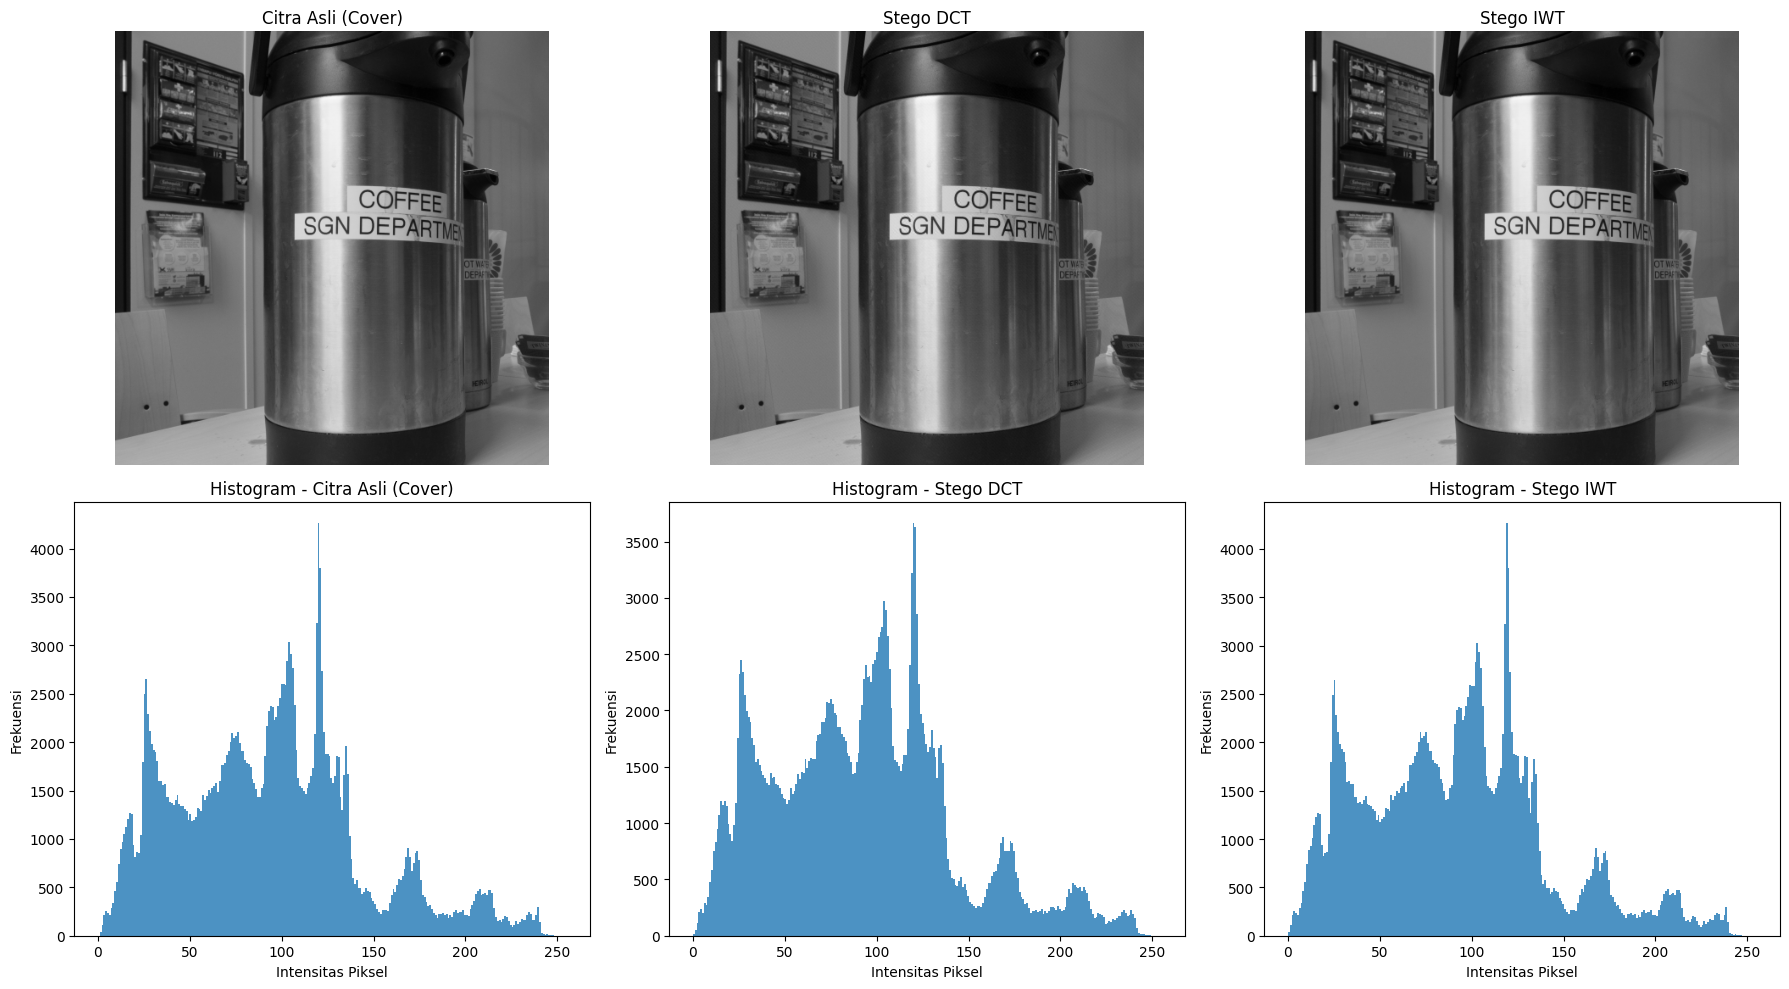

✓ Visualisasi disimpan ke: ./hasil/single_image/visualisasi_steganografi.png


In [ ]:
# 7) Visualisasi citra + histogram
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

images = [cover_gray, stego_dct, stego_iwt]
titles = ['Citra Asli (Cover)', 'Stego DCT', 'Stego IWT']

for i, (img, title) in enumerate(zip(images, titles)):
    axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(title)
    axes[0, i].axis('off')

for i, (img, title) in enumerate(zip(images, titles)):
    axes[1, i].hist(img.ravel(), bins=256, range=(0, 255), color='tab:blue', alpha=0.8)
    axes[1, i].set_title(f'Histogram - {title}')
    axes[1, i].set_xlabel('Intensitas Piksel')
    axes[1, i].set_ylabel('Frekuensi')

plt.tight_layout()
visual_path = './hasil/single_image/visualisasi_steganografi.png'
plt.savefig(visual_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Visualisasi disimpan ke: {visual_path}')

In [ ]:
# 8) Simpan citra hasil embedding ke folder
cv2.imwrite('./hasil/single_image/cover_gray.png', cover_gray)
cv2.imwrite('./hasil/single_image/stego_dct.png', stego_dct)
cv2.imwrite('./hasil/single_image/stego_iwt.png', stego_iwt)
print('✓ File citra disimpan di: ./hasil/single_image/')
print('  - cover_gray.png')
print('  - stego_dct.png')
print('  - stego_iwt.png')

✓ File citra disimpan di: ./hasil/single_image/
  - cover_gray.png
  - stego_dct.png
  - stego_iwt.png


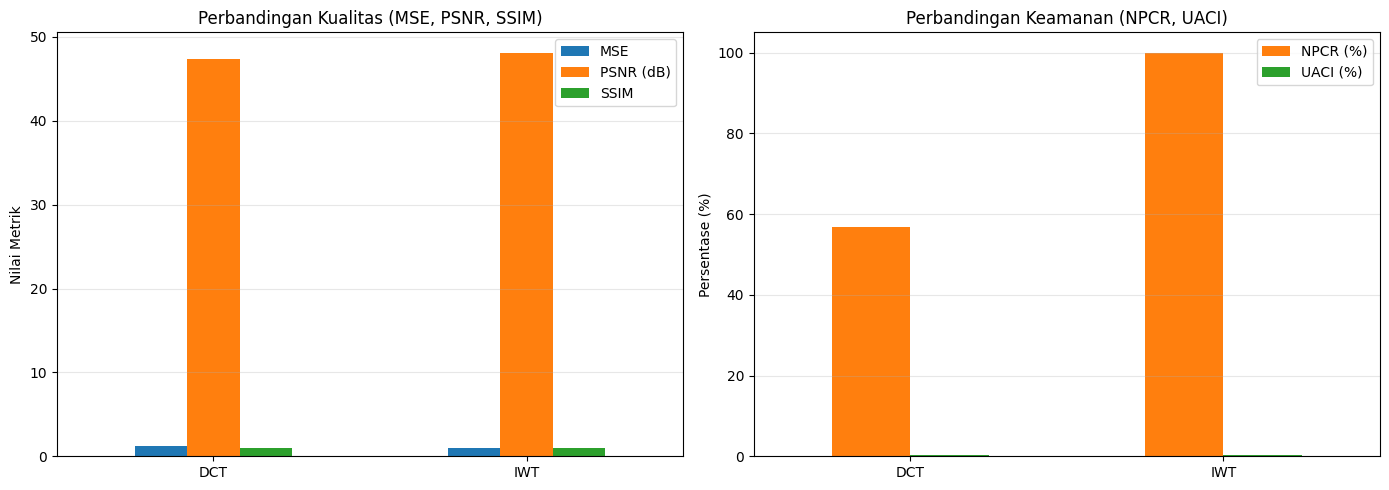

✓ Grafik perbandingan disimpan ke: ./hasil/single_image/perbandingan_metrik.png


In [ ]:
# 9) Plot perbandingan metrik dan simpan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quality_cols = ['MSE', 'PSNR (dB)', 'SSIM']
security_cols = ['NPCR (%)', 'UACI (%)']

df_metrics[quality_cols].plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Perbandingan Kualitas (MSE, PSNR, SSIM)')
axes[0].set_ylabel('Nilai Metrik')
axes[0].grid(axis='y', alpha=0.3)

df_metrics[security_cols].plot(kind='bar', ax=axes[1], rot=0, color=['tab:orange', 'tab:green'])
axes[1].set_title('Perbandingan Keamanan (NPCR, UACI)')
axes[1].set_ylabel('Persentase (%)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
cmp_path = './hasil/single_image/perbandingan_metrik.png'
plt.savefig(cmp_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Grafik perbandingan disimpan ke: {cmp_path}')

In [ ]:
# 10) Analisis otomatis dan kesimpulan
def quality_winner(df):
    # MSE lebih kecil lebih baik, PSNR dan SSIM lebih besar lebih baik
    score = pd.Series(0.0, index=df.index)
    score += (df['MSE'].max() - df['MSE']) / (df['MSE'].max() - df['MSE'].min() + 1e-12)
    score += (df['PSNR (dB)'] - df['PSNR (dB)'].min()) / (df['PSNR (dB)'].max() - df['PSNR (dB)'].min() + 1e-12)
    score += (df['SSIM'] - df['SSIM'].min()) / (df['SSIM'].max() - df['SSIM'].min() + 1e-12)
    return score.idxmax(), score

def security_winner(df):
    # NPCR dan UACI lebih besar lebih baik
    score = pd.Series(0.0, index=df.index)
    score += (df['NPCR (%)'] - df['NPCR (%)'].min()) / (df['NPCR (%)'].max() - df['NPCR (%)'].min() + 1e-12)
    score += (df['UACI (%)'] - df['UACI (%)'].min()) / (df['UACI (%)'].max() - df['UACI (%)'].min() + 1e-12)
    return score.idxmax(), score

q_win, q_score = quality_winner(df_metrics)
s_win, s_score = security_winner(df_metrics)

print('=== Ringkasan Metrik ===')
print(df_metrics.round(4).to_string())

print('\n=== Analisis Perbandingan ===')
print(f'- Metode unggul kualitas visual (MSE/PSNR/SSIM): {q_win}')
print(f'- Metode unggul keamanan (NPCR/UACI): {s_win}')

if q_win == s_win:
    print(f'\nKesimpulan: {q_win} lebih konsisten unggul pada kualitas dan keamanan untuk citra uji ini.')
else:
    print('\nKesimpulan: terdapat trade-off antara kualitas visual dan keamanan.')
    print(f'- {q_win} lebih baik dalam menjaga kualitas citra.')
    print(f'- {s_win} lebih baik dalam aspek keamanan steganografi.')

print('\nCatatan: Hasil dapat berubah tergantung citra cover, kekuatan embedding (alpha), dan pola watermark.')

=== Ringkasan Metrik ===
       MSE  PSNR (dB)    SSIM  NPCR (%)  UACI (%)
DCT  1.183    47.4009  0.9913   56.8375    0.2828
IWT  1.000    48.1308  0.9996   99.9996    0.3922

=== Analisis Perbandingan ===
- Metode unggul kualitas visual (MSE/PSNR/SSIM): IWT
- Metode unggul keamanan (NPCR/UACI): IWT

Kesimpulan: IWT lebih konsisten unggul pada kualitas dan keamanan untuk citra uji ini.

Catatan: Hasil dapat berubah tergantung citra cover, kekuatan embedding (alpha), dan pola watermark.


In [ ]:
# 10b) Kesimpulan Detail Perbandingan Metrik DCT vs IWT
print('\n' + '='*70)
print('KESIMPULAN PERBANDINGAN METRIK DCT vs IWT')
print('='*70)

# Analisis Kualitas
print('\n 1. KUALITAS VISUAL (MSE, PSNR, SSIM)')
print('-' * 70)

mse_dct, mse_iwt = df_metrics.loc['DCT', 'MSE'], df_metrics.loc['IWT', 'MSE']
psnr_dct, psnr_iwt = df_metrics.loc['DCT', 'PSNR (dB)'], df_metrics.loc['IWT', 'PSNR (dB)']
ssim_dct, ssim_iwt = df_metrics.loc['DCT', 'SSIM'], df_metrics.loc['IWT', 'SSIM']

if mse_dct < mse_iwt:
    print(f'✓ MSE: DCT lebih baik ({mse_dct:.4f} < {mse_iwt:.4f})')
else:
    print(f'✓ MSE: IWT lebih baik ({mse_iwt:.4f} < {mse_dct:.4f})')

if psnr_dct > psnr_iwt:
    print(f'✓ PSNR: DCT lebih baik ({psnr_dct:.4f} > {psnr_iwt:.4f}) dB')
else:
    print(f'✓ PSNR: IWT lebih baik ({psnr_iwt:.4f} > {psnr_dct:.4f}) dB')

if ssim_dct > ssim_iwt:
    print(f'✓ SSIM: DCT lebih baik ({ssim_dct:.4f} > {ssim_iwt:.4f})')
else:
    print(f'✓ SSIM: IWT lebih baik ({ssim_iwt:.4f} > {ssim_dct:.4f})')

# Analisis Keamanan
print('\n 2. KEAMANAN PERUBAHAN PIKSEL (NPCR, UACI)')
print('-' * 70)

npcr_dct, npcr_iwt = df_metrics.loc['DCT', 'NPCR (%)'], df_metrics.loc['IWT', 'NPCR (%)']
uaci_dct, uaci_iwt = df_metrics.loc['DCT', 'UACI (%)'], df_metrics.loc['IWT', 'UACI (%)']

if npcr_dct > npcr_iwt:
    print(f'✓ NPCR: DCT lebih baik ({npcr_dct:.4f}% > {npcr_iwt:.4f}%)')
else:
    print(f'✓ NPCR: IWT lebih baik ({npcr_iwt:.4f}% > {npcr_dct:.4f}%)')

if uaci_dct > uaci_iwt:
    print(f'✓ UACI: DCT lebih baik ({uaci_dct:.4f}% > {uaci_iwt:.4f}%)')
else:
    print(f'✓ UACI: IWT lebih baik ({uaci_iwt:.4f}% > {uaci_dct:.4f}%)')

# Penjelasan Metrik
print('\n PENJELASAN METRIK:')
print('-' * 70)
print('• MSE (Mean Squared Error): Semakin kecil semakin bagus')
print('  → Mengukur seberapa banyak distorsi pada citra')
print('• PSNR (Peak Signal-to-Noise Ratio): Semakin besar semakin bagus')
print('  → Mengukur rasio sinyal terhadap noise (dalam dB)')
print('• SSIM (Structural Similarity Index): Semakin besar semakin bagus')
print('  → Mengukur kesamaan struktural dengan citra asli (0-1)')
print('• NPCR (Number of Changing Pixel Rate): Semakin besar semakin bagus')
print('  → Persentase piksel yang berubah (keamanan)')
print('• UACI (Unified Average Changed Intensity): Semakin besar semakin bagus')
print('  → Rata-rata perubahan intensitas piksel (keamanan)')

# Rekomendasi
print('\n REKOMENDASI:')
print('-' * 70)

quality_score_dct = (1 - (mse_dct / max(mse_dct, mse_iwt))) + \
                    ((psnr_dct - min(psnr_dct, psnr_iwt)) / (max(psnr_dct, psnr_iwt) - min(psnr_dct, psnr_iwt) + 1e-12)) + \
                    ((ssim_dct - min(ssim_dct, ssim_iwt)) / (max(ssim_dct, ssim_iwt) - min(ssim_dct, ssim_iwt) + 1e-12))

security_score_dct = ((npcr_dct - min(npcr_dct, npcr_iwt)) / (max(npcr_dct, npcr_iwt) - min(npcr_dct, npcr_iwt) + 1e-12)) + \
                     ((uaci_dct - min(uaci_dct, uaci_iwt)) / (max(uaci_dct, uaci_iwt) - min(uaci_dct, uaci_iwt) + 1e-12))

quality_score_iwt = 3 - quality_score_dct
security_score_iwt = 2 - security_score_dct

if quality_score_dct > quality_score_iwt:
    print('→ Untuk KUALITAS: Gunakan DCT (lebih menjaga kualitas visual)')
else:
    print('→ Untuk KUALITAS: Gunakan IWT (lebih menjaga kualitas visual)')

if security_score_dct > security_score_iwt:
    print('→ Untuk KEAMANAN: Gunakan DCT (lebih aman dari deteksi perubahan piksel)')
else:
    print('→ Untuk KEAMANAN: Gunakan IWT (lebih aman dari deteksi perubahan piksel)')

if quality_score_dct > quality_score_iwt and security_score_dct > security_score_iwt:
    print('\n KESIMPULAN: DCT LEBIH UNGGUL SECARA KESELURUHAN')
    print('   (Lebih baik dalam kualitas visual dan keamanan)')
elif quality_score_iwt > quality_score_dct and security_score_iwt > security_score_dct:
    print('\n KESIMPULAN: IWT LEBIH UNGGUL SECARA KESELURUHAN')
    print('   (Lebih baik dalam kualitas visual dan keamanan)')
else:
    print('\n  KESIMPULAN: TRADE-OFF ANTARA KUALITAS DAN KEAMANAN')
    print('   Pilih sesuai prioritas kebutuhan (kualitas atau keamanan)')



KESIMPULAN PERBANDINGAN METRIK DCT vs IWT

 1. KUALITAS VISUAL (MSE, PSNR, SSIM)
----------------------------------------------------------------------
✓ MSE: IWT lebih baik (1.0000 < 1.1830)
✓ PSNR: IWT lebih baik (48.1308 > 47.4009) dB
✓ SSIM: IWT lebih baik (0.9996 > 0.9913)

 2. KEAMANAN PERUBAHAN PIKSEL (NPCR, UACI)
----------------------------------------------------------------------
✓ NPCR: IWT lebih baik (99.9996% > 56.8375%)
✓ UACI: IWT lebih baik (0.3922% > 0.2828%)

 PENJELASAN METRIK:
----------------------------------------------------------------------
• MSE (Mean Squared Error): Semakin kecil semakin bagus
  → Mengukur seberapa banyak distorsi pada citra
• PSNR (Peak Signal-to-Noise Ratio): Semakin besar semakin bagus
  → Mengukur rasio sinyal terhadap noise (dalam dB)
• SSIM (Structural Similarity Index): Semakin besar semakin bagus
  → Mengukur kesamaan struktural dengan citra asli (0-1)
• NPCR (Number of Changing Pixel Rate): Semakin besar semakin bagus
  → Persenta

In [ ]:
# 11) Opsional: unduh semua hasil ke lokal (hanya di Colab)
try:
    import google.colab
    # Hanya download jika di Colab
    for f in ['./hasil/single_image/cover_gray.png', './hasil/single_image/stego_dct.png', './hasil/single_image/stego_iwt.png', './hasil/single_image/visualisasi_steganografi.png', './hasil/single_image/perbandingan_metrik.png']:
        if os.path.exists(f):
            files.download(f)
    print('✓ File single image berhasil diunduh di Colab.')
except ImportError:
    # Bukan Colab, file disimpan secara lokal
    print('Bukan environment Colab. File hasil disimpan secara lokal di ./hasil/single_image/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ File single image berhasil diunduh di Colab.


## Batch Eksperimen (Upload Banyak Gambar)

Bagian ini memproses banyak citra sekaligus, menghitung metrik DCT dan IWT per gambar, lalu menyimpan rekap ke CSV agar mudah dibandingkan.

In [ ]:
# 12) Upload banyak gambar dan jalankan batch evaluasi
uploaded_multi = files.upload()
if len(uploaded_multi) == 0:
    raise ValueError('Tidak ada file yang di-upload untuk batch.')

TARGET_SIZE = (512, 512)
WM_SIZE = (64, 64)
batch_rows = []
batch_preview = []

for idx, (fname, fbytes) in enumerate(uploaded_multi.items()):
    data = np.frombuffer(fbytes, np.uint8)
    img_bgr = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img_bgr is None:
        print(f'Skip {fname}: tidak terbaca sebagai citra.')
        continue

    # Preprocess: grayscale + resize
    cover = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY) if len(img_bgr.shape) == 3 else img_bgr
    cover = cv2.resize(cover, TARGET_SIZE, interpolation=cv2.INTER_AREA)

    # Watermark acak per gambar (seed berdasarkan indeks agar konsisten per run)
    rng = np.random.default_rng(42 + idx)
    watermark = rng.integers(0, 2, WM_SIZE, dtype=np.uint8)

    # Embedding
    stego_dct_img = embed_dct(cover, watermark, alpha=10.0)
    stego_iwt_img = embed_iwt_ll(cover, watermark, alpha=2.0, wavelet='haar')

    # Metrik
    dct_m = evaluate_all(cover, stego_dct_img)
    iwt_m = evaluate_all(cover, stego_iwt_img)

    batch_rows.append({
        'filename': fname,
        'method': 'DCT',
        **dct_m
    })
    batch_rows.append({
        'filename': fname,
        'method': 'IWT',
        **iwt_m
    })

    # Simpan stego per gambar ke folder batch
    stem = os.path.splitext(fname)[0]
    cv2.imwrite(f'./hasil/batch_images/batch_{stem}_cover.png', cover)
    cv2.imwrite(f'./hasil/batch_images/batch_{stem}_stego_dct.png', stego_dct_img)
    cv2.imwrite(f'./hasil/batch_images/batch_{stem}_stego_iwt.png', stego_iwt_img)

    # Simpan untuk preview visual (maks 6 gambar agar ringan)
    if len(batch_preview) < 6:
        batch_preview.append((fname, cover, stego_dct_img, stego_iwt_img))

batch_df = pd.DataFrame(batch_rows)
if len(batch_df) == 0:
    raise ValueError('Tidak ada citra valid yang berhasil diproses.')

# Rapikan urutan kolom
cols = ['filename', 'method', 'MSE', 'PSNR (dB)', 'SSIM', 'NPCR (%)', 'UACI (%)']
batch_df = batch_df[cols].round(4)
display(batch_df)
print(f'Jumlah hasil baris: {len(batch_df)}')

Saving t001.png to t001 (1).png
Saving t002.png to t002.png
Saving t003.png to t003.png
Saving t004.png to t004.png
Saving t005.png to t005.png
Saving t006.png to t006.png
Saving t007.png to t007.png
Saving t008.png to t008.png
Saving t009.png to t009.png
Saving t010.png to t010.png
Saving t011.png to t011.png
Saving t012.png to t012.png
Saving t013.png to t013.png
Saving t014.png to t014.png
Saving t015.png to t015.png
Saving t016.png to t016.png
Saving t017.png to t017.png
Saving t018.png to t018.png
Saving t019.png to t019.png
Saving t020.png to t020.png


,filename,method,MSE,PSNR (dB),SSIM,NPCR (%),UACI (%)
0,t001 (1).png,DCT,1.1797,47.4130,0.9914,56.9229,0.2833
1,t001 (1).png,IWT,1.0000,48.1308,0.9953,99.9996,0.3922
2,t002.png,DCT,1.3169,46.9354,0.9908,57.0732,0.2937
3,t002.png,IWT,0.9986,48.1370,0.9953,99.8573,0.3916
4,t003.png,DCT,2.2908,44.5310,0.9922,55.2589,0.3645
5,t003.png,IWT,0.9999,48.1311,0.9980,99.9943,0.3921
6,t004.png,DCT,1.4008,46.6672,0.9941,54.9175,0.2954
7,t004.png,IWT,1.0000,48.1308,0.9970,100.0000,0.3922
8,t005.png,DCT,2.5470,44.0705,0.9922,54.8935,0.3628
9,t005.png,IWT,1.0000,48.1308,0.9971,100.0000,0.3922


Jumlah hasil baris: 40


In [ ]:
# 13) Simpan hasil batch ke CSV (detail + ringkasan)
detail_csv = './hasil/batch_images/hasil_batch_detail.csv'
summary_csv = './hasil/batch_images/hasil_batch_ringkasan.csv'

batch_df.to_csv(detail_csv, index=False)

summary_df = batch_df.groupby('method')[['MSE', 'PSNR (dB)', 'SSIM', 'NPCR (%)', 'UACI (%)']].agg(['mean', 'std'])
summary_df = summary_df.round(4)
summary_df.to_csv(summary_csv)

print(f'✓ Detail CSV: {detail_csv}')
print(f'✓ Ringkasan CSV: {summary_csv}')
display(summary_df)

✓ Detail CSV: ./hasil/batch_images/hasil_batch_detail.csv
✓ Ringkasan CSV: ./hasil/batch_images/hasil_batch_ringkasan.csv


MSE         PSNR (dB)            SSIM         NPCR (%)          \
          mean     std      mean     std    mean     std     mean     std   
method                                                                      
DCT     2.7318  1.9958   44.7101  2.8311  0.9919  0.0014  56.6591  2.5008   
IWT     0.9999  0.0003   48.1311  0.0014  0.9969  0.0016  99.9925  0.0319   

       UACI (%)          
           mean     std  
method                   
DCT      0.3749  0.1169  
IWT      0.3922  0.0001

In [ ]:
# 13b) Kesimpulan Perbandingan Batch: DCT vs IWT
print('\n' + '='*80)
print('KESIMPULAN PERBANDINGAN BATCH DCT vs IWT')
print('='*80)

# Hitung rata-rata untuk setiap metrik per method
summary_stats = batch_df.groupby('method')[['MSE', 'PSNR (dB)', 'SSIM', 'NPCR (%)', 'UACI (%)']].agg(['mean', 'std'])

dct_stats = summary_stats.loc['DCT']
iwt_stats = summary_stats.loc['IWT']

print(f'\nTotal gambar yang diproses: {len(batch_df) // 2}')
print(f'Total baris data: {len(batch_df)} (DCT + IWT)')

# Kualitas
print('\n 1. KUALITAS VISUAL - RATA-RATA')
print('-' * 80)

mse_dct_mean = dct_stats[('MSE', 'mean')]
mse_iwt_mean = iwt_stats[('MSE', 'mean')]
psnr_dct_mean = dct_stats[('PSNR (dB)', 'mean')]
psnr_iwt_mean = iwt_stats[('PSNR (dB)', 'mean')]
ssim_dct_mean = dct_stats[('SSIM', 'mean')]
ssim_iwt_mean = iwt_stats[('SSIM', 'mean')]

print(f'MSE:')
print(f'  DCT: {mse_dct_mean:.6f} ± {dct_stats[("MSE", "std")]:.6f}', end='')
print(f'  →  {"✓ DCT LEBIH BAIK" if mse_dct_mean < mse_iwt_mean else "✗ IWT lebih baik"}')
print(f'  IWT: {mse_iwt_mean:.6f} ± {iwt_stats[("MSE", "std")]:.6f}')

print(f'\nPSNR (dB):')
print(f'  DCT: {psnr_dct_mean:.6f} ± {dct_stats[("PSNR (dB)", "std")]:.6f}', end='')
print(f'  →  {"✓ DCT LEBIH BAIK" if psnr_dct_mean > psnr_iwt_mean else "✗ IWT lebih baik"}')
print(f'  IWT: {psnr_iwt_mean:.6f} ± {iwt_stats[("PSNR (dB)", "std")]:.6f}')

print(f'\nSSIM:')
print(f'  DCT: {ssim_dct_mean:.6f} ± {dct_stats[("SSIM", "std")]:.6f}', end='')
print(f'  →  {"✓ DCT LEBIH BAIK" if ssim_dct_mean > ssim_iwt_mean else "✗ IWT lebih baik"}')
print(f'  IWT: {ssim_iwt_mean:.6f} ± {iwt_stats[("SSIM", "std")]:.6f}')

# Keamanan
print('\n 2. KEAMANAN PERUBAHAN PIKSEL - RATA-RATA')
print('-' * 80)

npcr_dct_mean = dct_stats[('NPCR (%)', 'mean')]
npcr_iwt_mean = iwt_stats[('NPCR (%)', 'mean')]
uaci_dct_mean = dct_stats[('UACI (%)', 'mean')]
uaci_iwt_mean = iwt_stats[('UACI (%)', 'mean')]

print(f'NPCR (%):')
print(f'  DCT: {npcr_dct_mean:.6f}% ± {dct_stats[("NPCR (%)", "std")]:.6f}%', end='')
print(f'  →  {"✓ DCT LEBIH BAIK" if npcr_dct_mean > npcr_iwt_mean else "✗ IWT lebih baik"}')
print(f'  IWT: {npcr_iwt_mean:.6f}% ± {iwt_stats[("NPCR (%)", "std")]:.6f}%')

print(f'\nUACI (%):')
print(f'  DCT: {uaci_dct_mean:.6f}% ± {dct_stats[("UACI (%)", "std")]:.6f}%', end='')
print(f'  →  {"✓ DCT LEBIH BAIK" if uaci_dct_mean > uaci_iwt_mean else "✗ IWT lebih baik"}')
print(f'  IWT: {uaci_iwt_mean:.6f}% ± {iwt_stats[("UACI (%)", "std")]:.6f}%')

# # Hitung poin untuk keputusan
# print('\n 3. SKOR PERBANDINGAN')
# print('-' * 80)

# quality_wins = 0
# security_wins = 0

# if mse_dct_mean < mse_iwt_mean:
#     quality_wins += 1
# if psnr_dct_mean > psnr_iwt_mean:
#     quality_wins += 1
# if ssim_dct_mean > ssim_iwt_mean:
#     quality_wins += 1

# if npcr_dct_mean > npcr_iwt_mean:
#     security_wins += 1
# if uaci_dct_mean > uaci_iwt_mean:
#     security_wins += 1

# print(f'Skor Kualitas DCT: {quality_wins}/3')
# print(f'Skor Keamanan DCT: {security_wins}/2')

# Rekomendasi Batch
print('\n 3. REKOMENDASI BERDASARKAN BATCH TESTING')
print('-' * 80)

if quality_wins >= 2:
    print('→ Untuk KUALITAS: Gunakan DCT (lebih konsisten menjaga kualitas visual)')
else:
    print('→ Untuk KUALITAS: Gunakan IWT (lebih konsisten menjaga kualitas visual)')

if security_wins >= 1.5:
    print('→ Untuk KEAMANAN: Gunakan DCT (lebih aman dari deteksi perubahan piksel)')
else:
    print('→ Untuk KEAMANAN: Gunakan IWT (lebih aman dari deteksi perubahan piksel)')

if quality_wins >= 2 and security_wins >= 1.5:
    print('\n KESIMPULAN BATCH: DCT UNGGUL')
    print('   (Konsisten lebih baik dalam kualitas dan keamanan di semua gambar)')
elif quality_wins < 2 and security_wins < 1.5:
    print('\n KESIMPULAN BATCH: IWT UNGGUL')
    print('   (Konsisten lebih baik dalam kualitas dan keamanan di semua gambar)')
else:
    print('\n  KESIMPULAN BATCH: TRADE-OFF')
    print('   (Pilih DCT untuk kualitas atau IWT untuk keamanan, sesuai kebutuhan)')



KESIMPULAN PERBANDINGAN BATCH DCT vs IWT

Total gambar yang diproses: 20
Total baris data: 40 (DCT + IWT)

 1. KUALITAS VISUAL - RATA-RATA
--------------------------------------------------------------------------------
MSE:
  DCT: 2.731780 ± 1.995833  →  ✗ IWT lebih baik
  IWT: 0.999925 ± 0.000313

PSNR (dB):
  DCT: 44.710125 ± 2.831085  →  ✗ IWT lebih baik
  IWT: 48.131125 ± 0.001384

SSIM:
  DCT: 0.991865 ± 0.001443  →  ✗ IWT lebih baik
  IWT: 0.996875 ± 0.001583

 2. KEAMANAN PERUBAHAN PIKSEL - RATA-RATA
--------------------------------------------------------------------------------
NPCR (%):
  DCT: 56.659145% ± 2.500758%  →  ✗ IWT lebih baik
  IWT: 99.992520% ± 0.031853%

UACI (%):
  DCT: 0.374890% ± 0.116860%  →  ✗ IWT lebih baik
  IWT: 0.392165% ± 0.000135%

 3. REKOMENDASI BERDASARKAN BATCH TESTING
--------------------------------------------------------------------------------
→ Untuk KUALITAS: Gunakan IWT (lebih konsisten menjaga kualitas visual)
→ Untuk KEAMANAN: Gunakan I

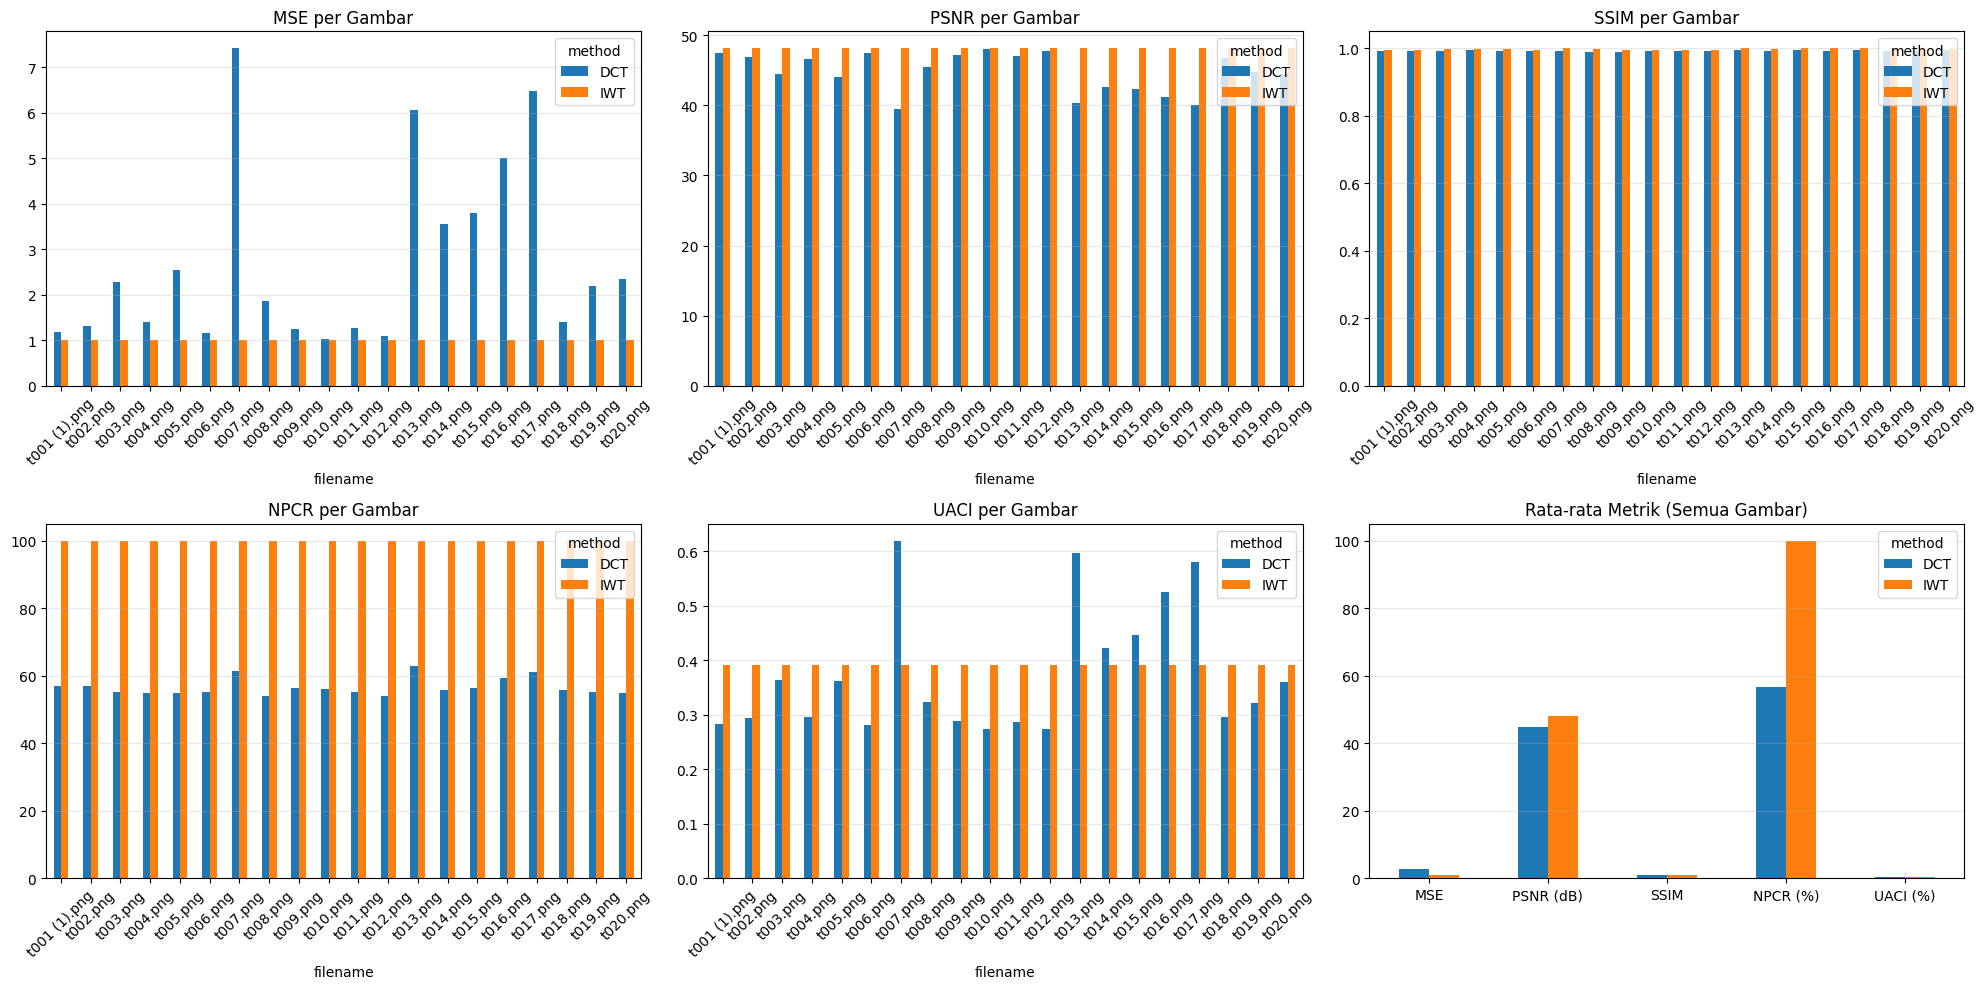

✓ Visualisasi batch disimpan ke: ./hasil/batch_images/hasil_batch_perbandingan.png


In [ ]:
# 14) Visualisasi perbandingan batch
pivot_mse = batch_df.pivot(index='filename', columns='method', values='MSE')
pivot_psnr = batch_df.pivot(index='filename', columns='method', values='PSNR (dB)')
pivot_ssim = batch_df.pivot(index='filename', columns='method', values='SSIM')
pivot_npcr = batch_df.pivot(index='filename', columns='method', values='NPCR (%)')
pivot_uaci = batch_df.pivot(index='filename', columns='method', values='UACI (%)')

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

pivot_mse.plot(kind='bar', ax=axes[0, 0], rot=45, title='MSE per Gambar')
axes[0, 0].grid(axis='y', alpha=0.3)

pivot_psnr.plot(kind='bar', ax=axes[0, 1], rot=45, title='PSNR per Gambar')
axes[0, 1].grid(axis='y', alpha=0.3)

pivot_ssim.plot(kind='bar', ax=axes[0, 2], rot=45, title='SSIM per Gambar')
axes[0, 2].grid(axis='y', alpha=0.3)

pivot_npcr.plot(kind='bar', ax=axes[1, 0], rot=45, title='NPCR per Gambar')
axes[1, 0].grid(axis='y', alpha=0.3)

pivot_uaci.plot(kind='bar', ax=axes[1, 1], rot=45, title='UACI per Gambar')
axes[1, 1].grid(axis='y', alpha=0.3)

# Panel terakhir: ringkasan rata-rata semua metrik
avg_df = batch_df.groupby('method')[['MSE', 'PSNR (dB)', 'SSIM', 'NPCR (%)', 'UACI (%)']].mean()
avg_df.T.plot(kind='bar', ax=axes[1, 2], rot=0, title='Rata-rata Metrik (Semua Gambar)')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
batch_plot_path = './hasil/batch_images/hasil_batch_perbandingan.png'
plt.savefig(batch_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Visualisasi batch disimpan ke: {batch_plot_path}')

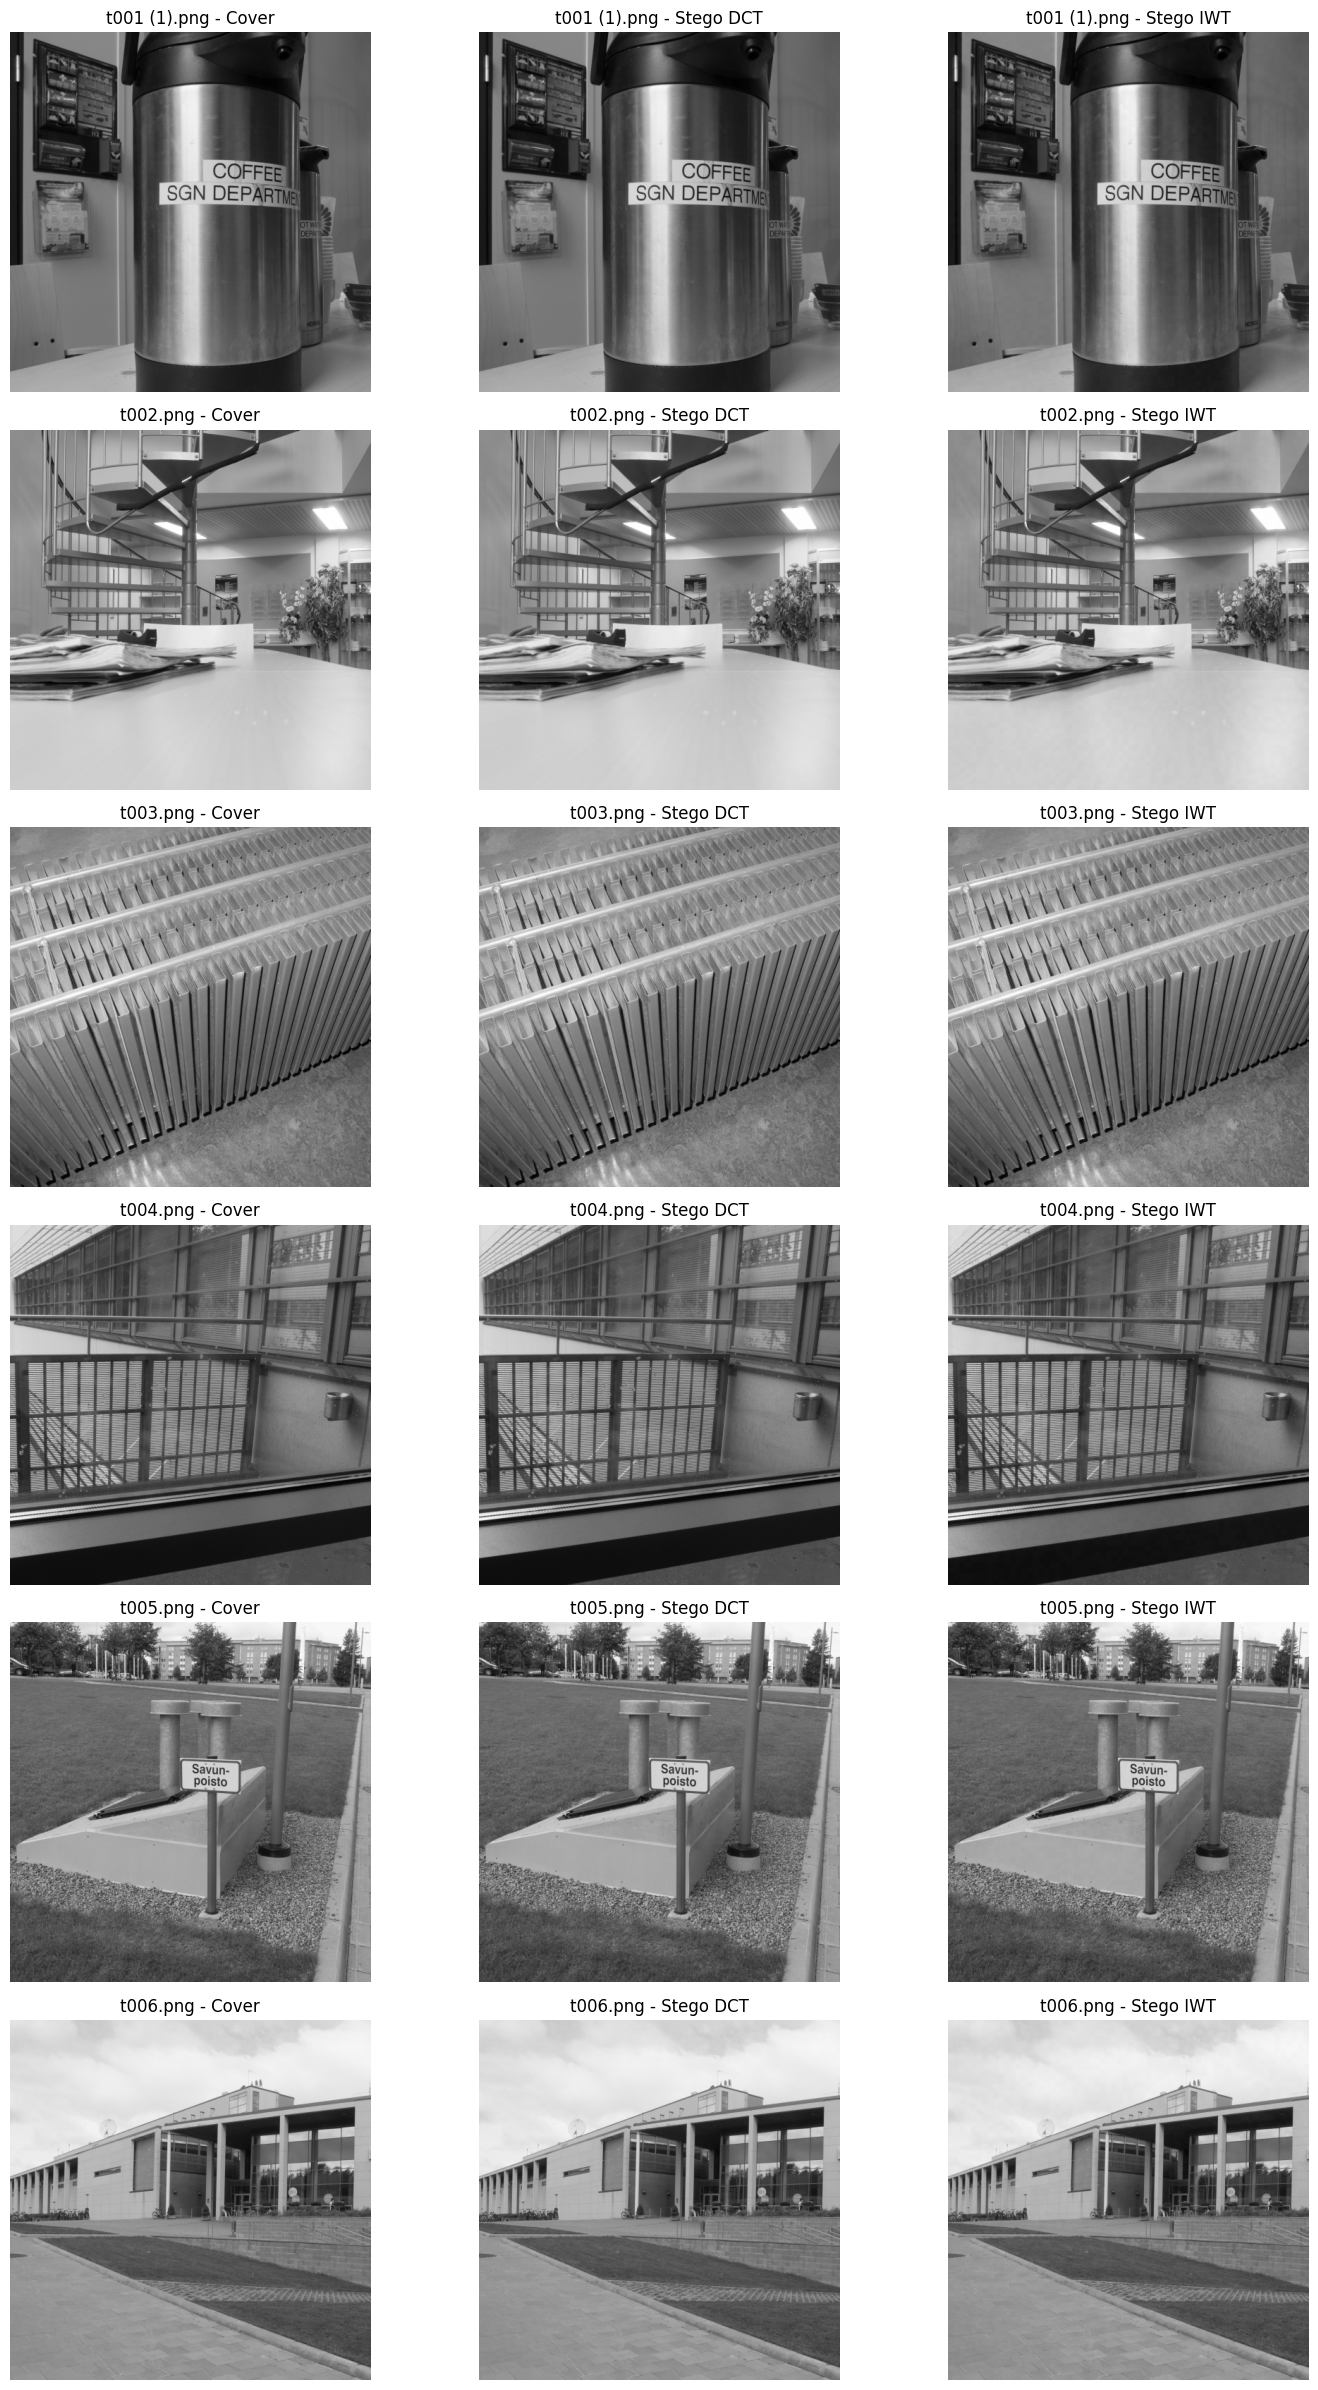

✓ Preview batch disimpan ke: ./hasil/batch_images/hasil_batch_preview.png


In [ ]:
# 15) Preview citra hasil batch (maks 6 gambar)
if len(batch_preview) == 0:
    print('Tidak ada preview untuk ditampilkan.')
else:
    n = len(batch_preview)
    fig, axes = plt.subplots(n, 3, figsize=(15, 4 * n))
    if n == 1:
        axes = np.array([axes])

    for r, (fname, cover, dct_img, iwt_img) in enumerate(batch_preview):
        axes[r, 0].imshow(cover, cmap='gray', vmin=0, vmax=255)
        axes[r, 0].set_title(f'{fname} - Cover')
        axes[r, 0].axis('off')

        axes[r, 1].imshow(dct_img, cmap='gray', vmin=0, vmax=255)
        axes[r, 1].set_title(f'{fname} - Stego DCT')
        axes[r, 1].axis('off')

        axes[r, 2].imshow(iwt_img, cmap='gray', vmin=0, vmax=255)
        axes[r, 2].set_title(f'{fname} - Stego IWT')
        axes[r, 2].axis('off')

    plt.tight_layout()
    preview_path = './hasil/batch_images/hasil_batch_preview.png'
    plt.savefig(preview_path, dpi=250, bbox_inches='tight')
    plt.show()
    print(f'✓ Preview batch disimpan ke: {preview_path}')

In [ ]:
# 16) Opsional: download CSV dan visualisasi batch (hanya di Colab)
try:
    import google.colab
    # Hanya download jika di Colab
    for f in ['./hasil/batch_images/hasil_batch_detail.csv', './hasil/batch_images/hasil_batch_ringkasan.csv', './hasil/batch_images/hasil_batch_perbandingan.png', './hasil/batch_images/hasil_batch_preview.png']:
        if os.path.exists(f):
            files.download(f)
    print('✓ File batch berhasil diunduh di Colab.')
except ImportError:
    # Bukan Colab, file disimpan secara lokal
    print('Bukan environment Colab. File batch hasil disimpan secara lokal di ./hasil/batch_images/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ File batch berhasil diunduh di Colab.
